# Swapping distance (Puccetti 2017) — §2.3.3 Bernton et al. (2019)

On voit le Wasserstein comme un problème d'assignation sur une permutation \(\sigma\) :

\[
C(\sigma) = \sum_{i=1}^K 
ho(y_i, z_{\sigma(i)})^p
\]

Algorithme greedy de **swaps** : pour tous \(1 \le i < j \le K\), si

\[

ho(y_i,z_{\sigma(i)})^p + 
ho(y_j,z_{\sigma(j)})^p \;>\; 
ho(y_i,z_{\sigma(j)})^p + 
ho(y_j,z_{\sigma(i)})^p
\]

alors on échange \(\sigma(i)\) et \(\sigma(j)\). On répète des **sweeps** jusqu'à stabilité (ou `max_sweeps`).

- **Init recommandée** : \(\sigma\) issu du tri de Hilbert (coût \(K\log K\)) ou *warm-start* (σ de l'itération précédente en SMC).
- **Bornes** (par construction) : \(W_p \le S_p \le H_p\)

Ce notebook compare : **NumPy**, **Numba**, **JAX (jit)** et **JAX (vmap batch)**.


In [1]:

import sys, pathlib, importlib.util, time, warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import linear_sum_assignment
import numba

# ── JAX optionnel ─────────────────────────────────────────────────────────
try:
    import jax
    import jax.numpy as jnp
    from jax import lax
    JAX_OK = True
    print('JAX:', jax.__version__)
except Exception as e:
    JAX_OK = False
    print('JAX non disponible:', str(e)[:120])

print('Numba:', numba.__version__)

# ── Charger hilbert.py (Custom PCA+2D Hilbert) ────────────────────────────
_CORE = pathlib.Path('/Users/antoineluciano/Documents/Recherche/permABC/permabc/core')
if str(_CORE) not in sys.path:
    sys.path.insert(0, str(_CORE))

spec = importlib.util.spec_from_file_location('hilbert', _CORE / 'hilbert.py')
_hmod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(_hmod)

# ── Utils ─────────────────────────────────────────────────────────────────
def simulate(K, d, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    return rng.normal(0, 3, (K, d)), rng.normal(0, 3, (K, d))


def build_cost(y, z, p=2):
    # cost[i,j] = ||y_i - z_j||^p  (L2)
    diff = y[:, None, :] - z[None, :, :]
    return np.sum(diff**2, axis=-1) ** (p / 2)


def lsa_sigma(cost):
    # Permutation optimale σ_LSA: σ[i] = j
    r, c = linear_sum_assignment(cost)
    sigma = np.empty(cost.shape[0], dtype=np.int64)
    sigma[r] = c
    return sigma


def hilbert_sigma(y, z, idx_fn=None):
    # Permutation Hilbert σ_H : σ[i] = j
    if idx_fn is None:
        idx_fn = _hmod._points_to_hilbert_indices
    hy = np.argsort(idx_fn(y))
    hz = np.argsort(idx_fn(z))
    return hz[np.argsort(hy)]


def dist_from_sigma(cost, sigma, p=2):
    return (cost[np.arange(cost.shape[0]), sigma].mean()) ** (1 / p)


def hamming(s1, s2):
    return float(np.mean(s1 != s2))

print('Setup OK')


JAX non disponible: This version of jaxlib was built using AVX instructions, which your CPU and/or operating system do not support. This err
Numba: 0.53.0
Setup OK


In [2]:

# ==========================================================================
# 1) Swapping (NumPy) — implémentation directe du §2.3.3
# ==========================================================================

def swap_greedy_numpy(cost, sigma_init, max_sweeps=50):
    # Applique des sweeps i<j jusqu'à stabilité.
    sigma = np.array(sigma_init, dtype=np.int64)
    K = len(sigma)
    swaps_total = 0

    for sweep in range(max_sweeps):
        changed = False
        for i in range(K):
            si = sigma[i]
            for j in range(i + 1, K):
                sj = sigma[j]
                if cost[i, si] + cost[j, sj] > cost[i, sj] + cost[j, si]:
                    sigma[i] = sj
                    sigma[j] = si
                    si = sigma[i]
                    changed = True
                    swaps_total += 1
        if not changed:
            return sigma, sweep + 1, swaps_total

    return sigma, max_sweeps, swaps_total


def swapping_distance_numpy(y, z, p=2, sigma_init=None, max_sweeps=50):
    cost = build_cost(y, z, p=p)
    if sigma_init is None:
        sigma_init = hilbert_sigma(y, z)
    sigma, sweeps, swaps_total = swap_greedy_numpy(cost, sigma_init, max_sweeps=max_sweeps)
    return dist_from_sigma(cost, sigma, p=p), sigma, sweeps, swaps_total

# Quick sanity
rng = np.random.default_rng(0)
y, z = simulate(10, 2, rng=rng)
cost = build_cost(y, z)
W = dist_from_sigma(cost, lsa_sigma(cost))
H = dist_from_sigma(cost, hilbert_sigma(y, z))
S, sS, sweeps, swaps = swapping_distance_numpy(y, z)
print(f'W={W:.4f}  S={S:.4f}  H={H:.4f}  (ok={W<=S<=H})  sweeps={sweeps} swaps={swaps}')


W=1.9926  S=1.9926  H=2.5740  (ok=True)  sweeps=3 swaps=6


In [3]:

# ==========================================================================
# 2) Swapping (Numba) — même logique mais compilée
# ==========================================================================

@numba.njit
def _swap_greedy_numba(cost, sigma, max_sweeps):
    K = len(sigma)
    swaps_total = 0
    for sweep in range(max_sweeps):
        changed = False
        for i in range(K):
            si = sigma[i]
            for j in range(i + 1, K):
                sj = sigma[j]
                if cost[i, si] + cost[j, sj] > cost[i, sj] + cost[j, si]:
                    sigma[i] = sj
                    sigma[j] = si
                    si = sigma[i]
                    changed = True
                    swaps_total += 1
        if not changed:
            return sigma, sweep + 1, swaps_total
    return sigma, max_sweeps, swaps_total

# Warmup JIT
_swap_greedy_numba(np.ones((3,3), np.float64), np.array([0,1,2], np.int64), 5)
print('Numba warmup OK')


def swapping_distance_numba(y, z, p=2, sigma_init=None, max_sweeps=50):
    cost = build_cost(y, z, p=p)
    if sigma_init is None:
        sigma_init = hilbert_sigma(y, z)
    sigma = np.array(sigma_init, dtype=np.int64)
    sigma, sweeps, swaps_total = _swap_greedy_numba(cost, sigma, max_sweeps)
    return dist_from_sigma(cost, sigma, p=p), sigma, int(sweeps), int(swaps_total)

# Quick sanity
rng = np.random.default_rng(1)
y, z = simulate(50, 3, rng=rng)
cost = build_cost(y, z)
W = dist_from_sigma(cost, lsa_sigma(cost))
H = dist_from_sigma(cost, hilbert_sigma(y, z))
S, sS, sweeps, swaps = swapping_distance_numba(y, z)
print(f'W={W:.4f}  S={S:.4f}  H={H:.4f}  (ok={W<=S<=H})  sweeps={sweeps} swaps={swaps}')


Numba warmup OK
W=2.6905  S=2.8097  H=6.3493  (ok=True)  sweeps=4 swaps=133


In [4]:

# ==========================================================================
# 3) Swapping (JAX) — jit + while_loop + scan sur paires (i<j)
# ==========================================================================

if not JAX_OK:
    print('JAX non dispo → ignoré')
else:
    def make_swap_jax(K, max_sweeps=50):
        ii, jj = np.triu_indices(K, k=1)
        pairs = jnp.array(np.stack([ii, jj], axis=1), dtype=jnp.int32)

        @jax.jit
        def swap_fn(cost, sigma_init):
            def one_pair(sigma, ij):
                i, j = ij[0], ij[1]
                si, sj = sigma[i], sigma[j]
                better = (cost[i, sj] + cost[j, si]) < (cost[i, si] + cost[j, sj])
                new_si = jnp.where(better, sj, si)
                new_sj = jnp.where(better, si, sj)
                sigma2 = sigma.at[i].set(new_si).at[j].set(new_sj)
                return sigma2, better.astype(jnp.int32)

            def do_sweep(carry):
                sigma, _, sweeps = carry
                sigma, did_swap = lax.scan(one_pair, sigma, pairs)
                return sigma, did_swap.sum(), sweeps + 1

            def cond(carry):
                _, n_swaps, sweeps = carry
                return jnp.logical_and(n_swaps > 0, sweeps < max_sweeps)

            sigma, n_swaps, sweeps = lax.while_loop(
                cond,
                do_sweep,
                (sigma_init, jnp.int32(1), jnp.int32(0))
            )
            return sigma, sweeps

        return swap_fn

    # Quick sanity
    rng = np.random.default_rng(2)
    y, z = simulate(50, 3, rng=rng)
    cost_np = build_cost(y, z, p=2).astype(np.float32)
    sig0 = hilbert_sigma(y, z).astype(np.int32)

    fn = make_swap_jax(50)
    sigma_out, sweeps = fn(jnp.array(cost_np), jnp.array(sig0))

    cost64 = build_cost(y, z, p=2)
    W = dist_from_sigma(cost64, lsa_sigma(cost64))
    H = dist_from_sigma(cost64, hilbert_sigma(y, z))
    S = dist_from_sigma(cost64, np.array(sigma_out), p=2)
    print(f'W={W:.4f}  S={S:.4f}  H={H:.4f}  (ok={W<=S<=H})  sweeps={int(sweeps)}')


JAX non dispo → ignoré


Grid 5x6 with N_MC=200 ...
  K= 5 done
  K= 10 done
  K= 20 done
  K= 50 done
  K= 100 done


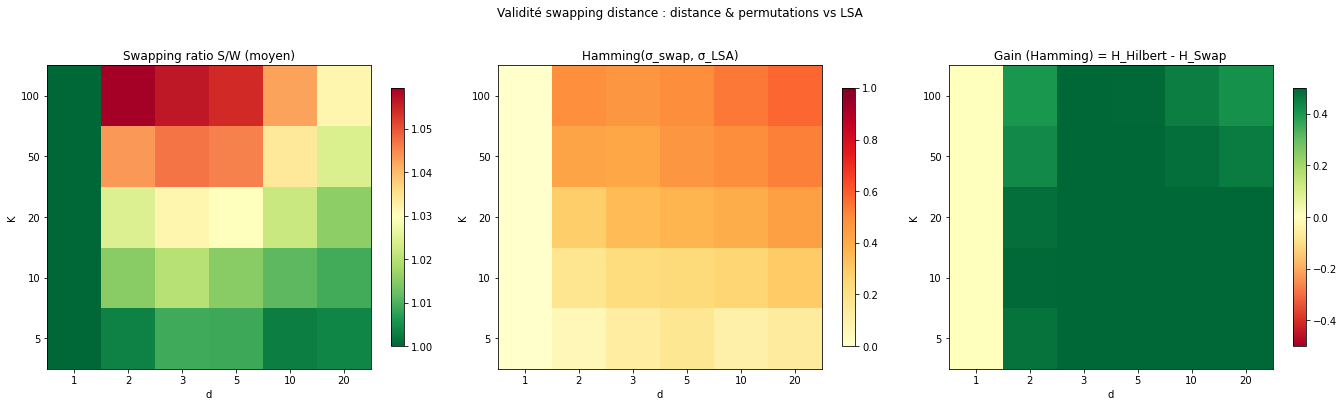

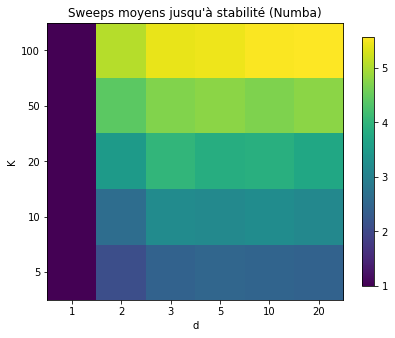

Attendu : S/W proche de 1 et gain Hamming positif.


In [5]:

# ==========================================================================
# 4) Validité sur grille (K,d) : ratio S/W + Hamming(σ_swap, σ_LSA)
# ==========================================================================

K_GRID = [5, 10, 20, 50, 100]
D_GRID = [1, 2, 3, 5, 10, 20]
N_MC   = 200
p = 2

ratio_S_W = np.zeros((len(K_GRID), len(D_GRID)))
ham_S_LSA = np.zeros((len(K_GRID), len(D_GRID)))
ham_H_LSA = np.zeros((len(K_GRID), len(D_GRID)))
sweeps_mean = np.zeros((len(K_GRID), len(D_GRID)))

print(f'Grid {len(K_GRID)}x{len(D_GRID)} with N_MC={N_MC} ...')
for i, K in enumerate(K_GRID):
    for j, d in enumerate(D_GRID):
        rng = np.random.default_rng(i * 1000 + j)
        r_list = []
        hs_list = []
        hh_list = []
        sw_list = []
        for _ in range(N_MC):
            y, z = simulate(K, d, rng=rng)
            cost = build_cost(y, z, p=p)
            s_lsa = lsa_sigma(cost)
            W = dist_from_sigma(cost, s_lsa, p=p)

            s_h = hilbert_sigma(y, z)
            S, s_swap, sweeps, _ = swapping_distance_numba(y, z, p=p, sigma_init=s_h, max_sweeps=50)

            r_list.append(S / W)
            hs_list.append(hamming(s_swap, s_lsa))
            hh_list.append(hamming(s_h, s_lsa))
            sw_list.append(sweeps)

        ratio_S_W[i, j] = float(np.mean(r_list))
        ham_S_LSA[i, j] = float(np.mean(hs_list))
        ham_H_LSA[i, j] = float(np.mean(hh_list))
        sweeps_mean[i, j] = float(np.mean(sw_list))
    print('  K=', K, 'done')

# ── Heatmaps ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))

im = axes[0].imshow(ratio_S_W, aspect='auto', cmap='RdYlGn_r', vmin=1.0,
                    vmax=min(3.0, float(np.nanmax(ratio_S_W))), origin='lower')
axes[0].set_title('Swapping ratio S/W (moyen)')
axes[0].set_xticks(range(len(D_GRID))); axes[0].set_xticklabels(D_GRID)
axes[0].set_yticks(range(len(K_GRID))); axes[0].set_yticklabels(K_GRID)
axes[0].set_xlabel('d'); axes[0].set_ylabel('K')
plt.colorbar(im, ax=axes[0], shrink=0.85)

im = axes[1].imshow(ham_S_LSA, aspect='auto', cmap='YlOrRd', vmin=0.0, vmax=1.0, origin='lower')
axes[1].set_title('Hamming(σ_swap, σ_LSA)')
axes[1].set_xticks(range(len(D_GRID))); axes[1].set_xticklabels(D_GRID)
axes[1].set_yticks(range(len(K_GRID))); axes[1].set_yticklabels(K_GRID)
axes[1].set_xlabel('d'); axes[1].set_ylabel('K')
plt.colorbar(im, ax=axes[1], shrink=0.85)

gain = ham_H_LSA - ham_S_LSA
im = axes[2].imshow(gain, aspect='auto', cmap='RdYlGn', vmin=-0.5, vmax=0.5, origin='lower')
axes[2].set_title('Gain (Hamming) = H_Hilbert - H_Swap')
axes[2].set_xticks(range(len(D_GRID))); axes[2].set_xticklabels(D_GRID)
axes[2].set_yticks(range(len(K_GRID))); axes[2].set_yticklabels(K_GRID)
axes[2].set_xlabel('d'); axes[2].set_ylabel('K')
plt.colorbar(im, ax=axes[2], shrink=0.85)

plt.suptitle('Validité swapping distance : distance & permutations vs LSA', y=1.02)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4.8))
im = plt.imshow(sweeps_mean, aspect='auto', cmap='viridis', origin='lower')
plt.title("Sweeps moyens jusqu'à stabilité (Numba)")
plt.xticks(range(len(D_GRID)), D_GRID)
plt.yticks(range(len(K_GRID)), K_GRID)
plt.xlabel('d'); plt.ylabel('K')
plt.colorbar(im, shrink=0.9)
plt.tight_layout(); plt.show()

print('Attendu : S/W proche de 1 et gain Hamming positif.')


d= 2 done
d= 5 done
d= 10 done


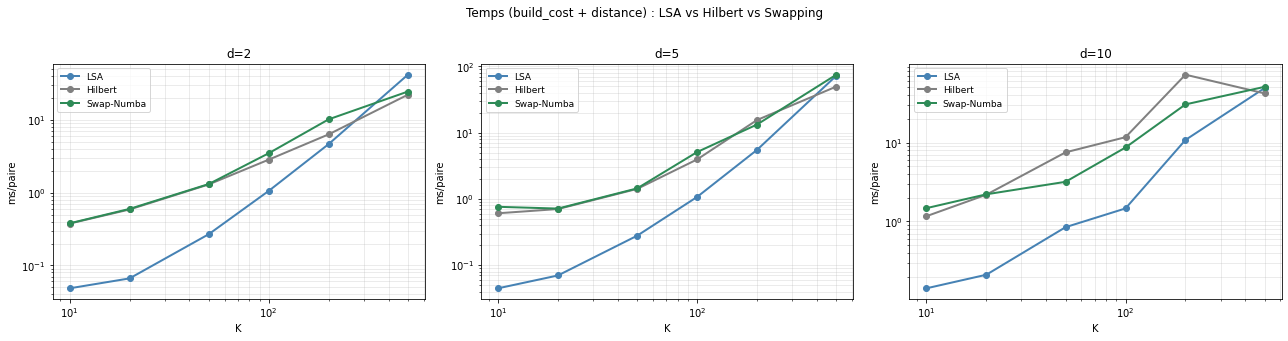

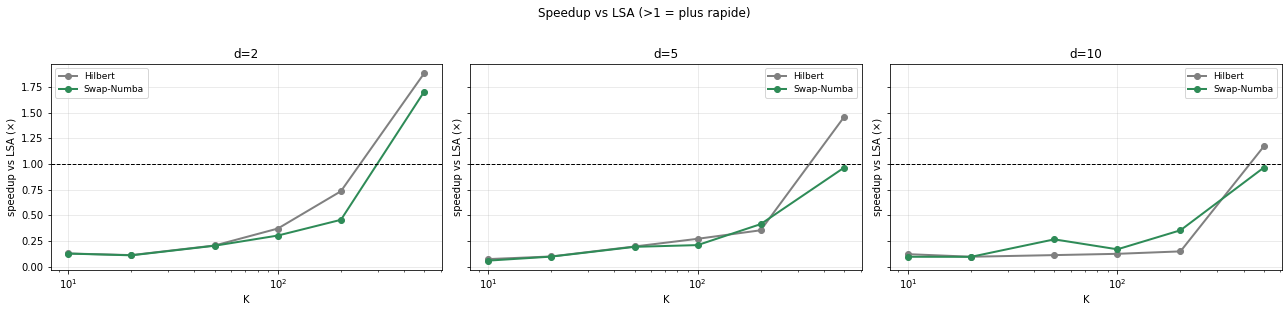

In [6]:

# ==========================================================================
# 5) Benchmark vitesse : LSA vs Hilbert vs Swap (Numba / JAX)
# ==========================================================================

K_BENCH = [10, 20, 50, 100, 200, 500]
D_BENCH = [2, 5, 10]
N_REP   = 200
p = 2

method_names = ['LSA', 'Hilbert', 'Swap-Numba'] + (['Swap-JAX'] if JAX_OK else [])
results = {name: np.zeros((len(K_BENCH), len(D_BENCH))) for name in method_names}

for j, d in enumerate(D_BENCH):
    for i, K in enumerate(K_BENCH):
        rng = np.random.default_rng(K * 100 + d)
        samples = [simulate(K, d, rng=rng) for _ in range(N_REP)]

        t0 = time.perf_counter()
        for y, z in samples:
            cost = build_cost(y, z, p=p)
            s = lsa_sigma(cost)
            dist_from_sigma(cost, s, p=p)
        results['LSA'][i, j] = (time.perf_counter() - t0) / N_REP * 1000

        t0 = time.perf_counter()
        for y, z in samples:
            cost = build_cost(y, z, p=p)
            s = hilbert_sigma(y, z)
            dist_from_sigma(cost, s, p=p)
        results['Hilbert'][i, j] = (time.perf_counter() - t0) / N_REP * 1000

        t0 = time.perf_counter()
        for y, z in samples:
            swapping_distance_numba(y, z, p=p, sigma_init=None, max_sweeps=50)
        results['Swap-Numba'][i, j] = (time.perf_counter() - t0) / N_REP * 1000

        if JAX_OK:
            fn = make_swap_jax(K, max_sweeps=50)
            y0, z0 = samples[0]
            cost0 = build_cost(y0, z0, p=p).astype(np.float32)
            sig0 = hilbert_sigma(y0, z0).astype(np.int32)
            fn(jnp.array(cost0), jnp.array(sig0))

            t0 = time.perf_counter()
            for y, z in samples:
                cost = build_cost(y, z, p=p).astype(np.float32)
                sig = hilbert_sigma(y, z).astype(np.int32)
                fn(jnp.array(cost), jnp.array(sig))
            results['Swap-JAX'][i, j] = (time.perf_counter() - t0) / N_REP * 1000

    print('d=', d, 'done')

colors = {'LSA': 'steelblue', 'Hilbert': 'gray', 'Swap-Numba': 'seagreen', 'Swap-JAX': 'darkorange'}

fig, axes = plt.subplots(1, len(D_BENCH), figsize=(6 * len(D_BENCH), 4.6), sharey=False)
for ax, d, j in zip(axes, D_BENCH, range(len(D_BENCH))):
    for name, mat in results.items():
        ax.plot(K_BENCH, mat[:, j], marker='o', lw=2, color=colors.get(name, 'black'), label=name)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_title(f'd={d}')
    ax.set_xlabel('K'); ax.set_ylabel('ms/paire')
    ax.grid(True, alpha=0.3, which='both'); ax.legend(fontsize=9)

plt.suptitle('Temps (build_cost + distance) : LSA vs Hilbert vs Swapping', y=1.02)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, len(D_BENCH), figsize=(6 * len(D_BENCH), 4.2), sharey=True)
for ax, d, j in zip(axes, D_BENCH, range(len(D_BENCH))):
    base = results['LSA'][:, j]
    for name in results:
        if name == 'LSA':
            continue
        speed = base / np.maximum(results[name][:, j], 1e-9)
        ax.plot(K_BENCH, speed, marker='o', lw=2, color=colors.get(name, 'black'), label=name)
    ax.axhline(1.0, color='black', ls='--', lw=1)
    ax.set_xscale('log')
    ax.set_title(f'd={d}')
    ax.set_xlabel('K'); ax.set_ylabel('speedup vs LSA (×)')
    ax.grid(True, alpha=0.3); ax.legend(fontsize=9)

plt.suptitle('Speedup vs LSA (>1 = plus rapide)', y=1.02)
plt.tight_layout(); plt.show()


## Lecture rapide

- **Distance** : `S/W` proche de 1 = très bon (S approx Wasserstein).
- **Permutations** : `Hamming(σ_swap, σ_LSA)` compare les appariements (0 = identique).
- **Gain** : `H_Hilbert - H_Swap` > 0 signifie que les swaps rapprochent la permutation de l'optimal LSA.

Prochaine étape naturelle : utiliser **warm-start** (σ_{t-1}) dans l'ABC-SMC pour réduire le nb de sweeps.
